<a href="https://colab.research.google.com/github/riya16chouhan/loan-approval-prediction-system/blob/main/Loan_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THINGS TO DO IN ML PROJECT
---
1. Importing libraries
2. Loading and Understanding data
3. Exploratory Data Analysis (EDA)
4. Data PreProcessing
5. Feature Engineering
6. Train - Test Split
7. Scale (Standard Scalar: equalize mean and standart deviation) (Standard Scalar = x-mean/std.)
8. Logistic Regression (Train) (scikit learn)
9. Model Evaluation (accuracy_score, classification_report, precision, recall, confusion matrix, ROC-AUC, Curve)
10. Hyperparameter Tunning
11. Feature Importance
12. Log Transformer (To fix skewness when our model is Skewed)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('loan-train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape #(for rows and columns)

(614, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
# % of null values:
Missing = pd.DataFrame({
    'Count of Null Values': df.isnull().sum(),
    'Percentage of Null Values': (df.isnull().sum()/len(df))*100
})
Missing

,Count of Null Values,Percentage of Null Values
Loan_ID,0,0.000000
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Education,0,0.000000
Self_Employed,32,5.211726
ApplicantIncome,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130


In [8]:
#Values greater than 0:
Missing[Missing['Count of Null Values'] > 0]

,Count of Null Values,Percentage of Null Values
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


<Axes: xlabel='count', ylabel='Loan_Status'>

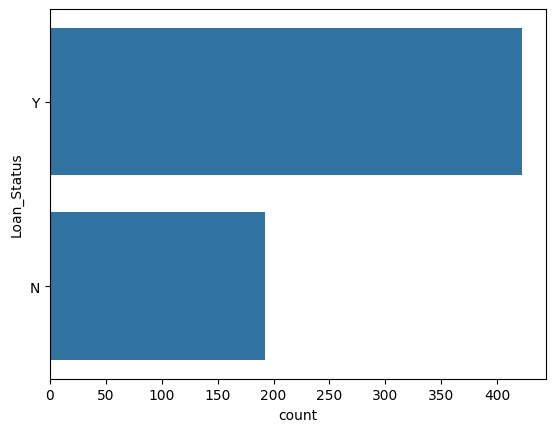

In [9]:
sns.countplot(df["Loan_Status"])

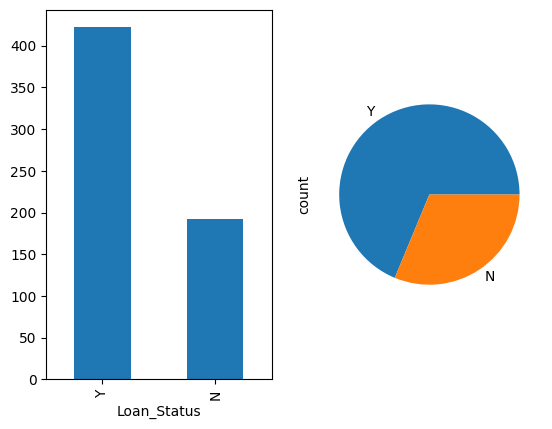

In [10]:
def distribution(column):
  counts=column.value_counts()

  plt.subplot(1,2,1)
  counts.plot(kind="bar")

  plt.subplot(1,2,2)
  counts.plot(kind="pie")
distribution(df["Loan_Status"])

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

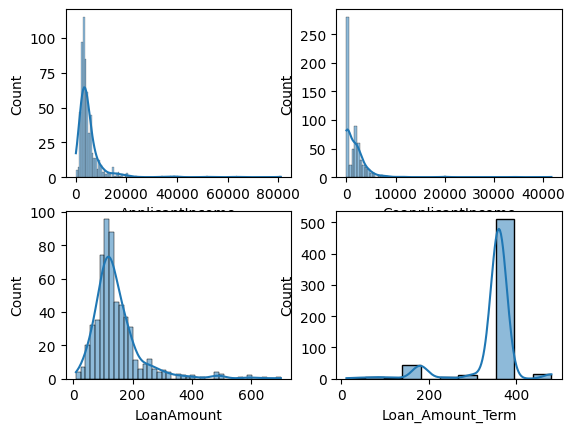

In [11]:
#Univariate analysis - distribution of single column(Continuous only)

plt.subplot(2,2,1)
sns.histplot(df["ApplicantIncome"],kde=True)

plt.subplot(2,2,2)
sns.histplot(df["CoapplicantIncome"],kde=True)

plt.subplot(2,2,3)
sns.histplot(df["LoanAmount"],kde=True)

plt.subplot(2,2,4)
sns.histplot(df["Loan_Amount_Term"],kde=True)

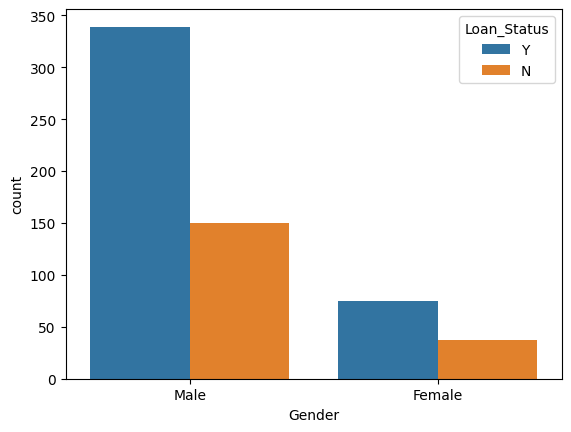

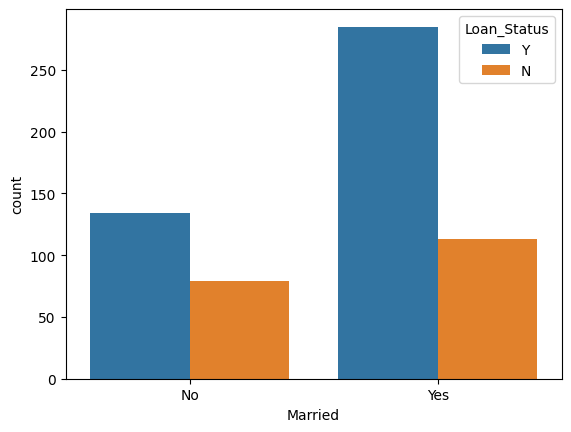

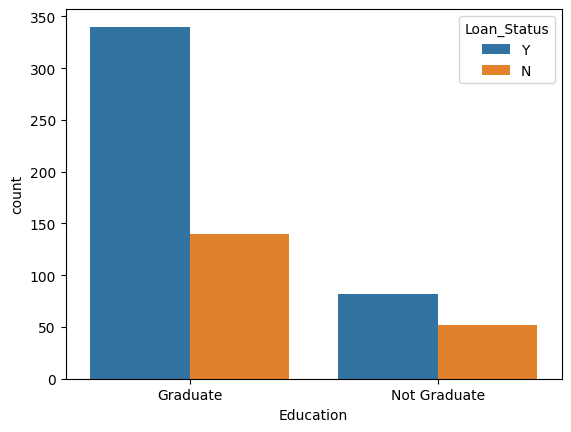

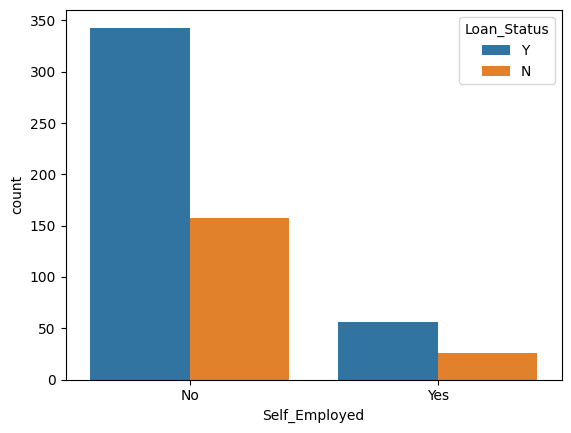

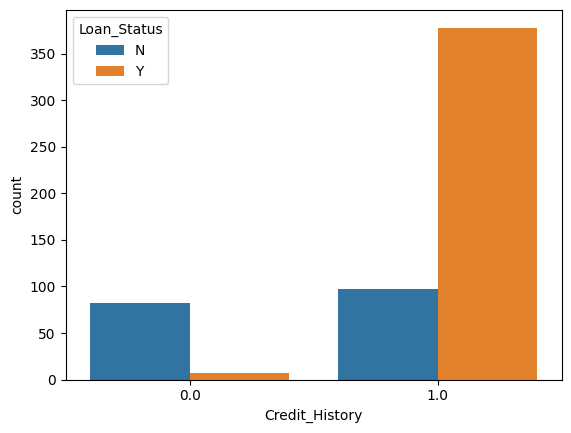

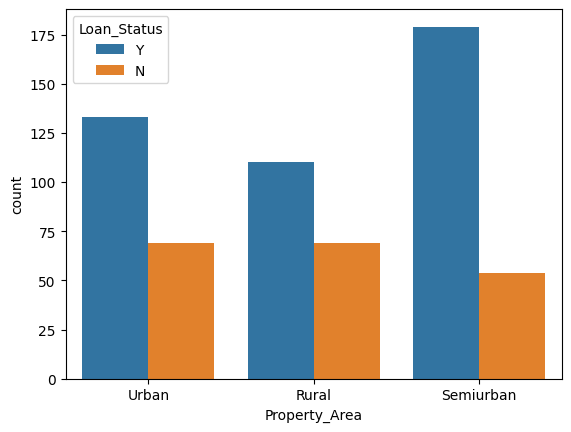

In [12]:
#Bivariate analysis - for two column (Categorical v/s loan_status))

cat_features=['Gender','Married','Education','Self_Employed','Credit_History','Property_Area']
for i in cat_features:
  sns.countplot(x=i,hue='Loan_Status',data=df)
  plt.show()

In [13]:
df_copy=df.copy()

In [14]:
df_copy["Loan_Status"]=df_copy["Loan_Status"].map({'Y':1,'N':0})

<Axes: xlabel='Loan_Status', ylabel='count'>

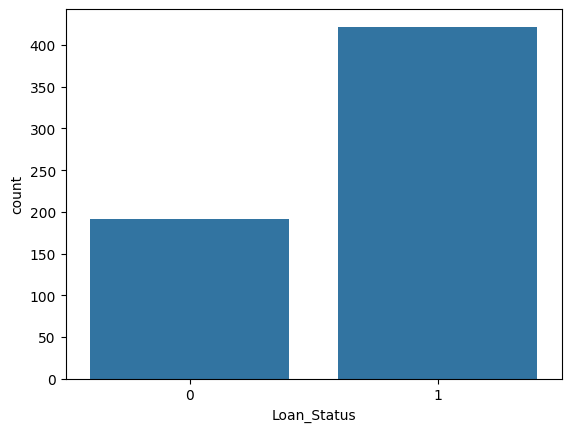

In [15]:
sns.countplot(x='Loan_Status',data=df_copy)

In [16]:
#heat map can be only integer vs integer
df_copy = df.copy()
df_copy.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


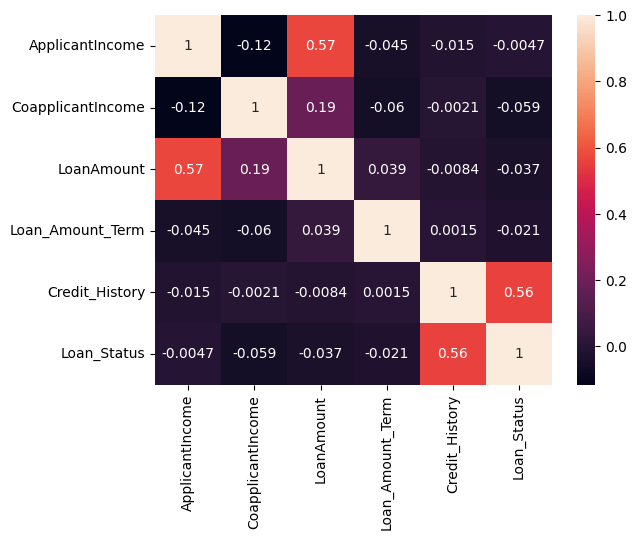

In [17]:
df_copy['Loan_Status'] = df_copy['Loan_Status'].map({'Y':1,'N':0})
sns.heatmap(df_copy.select_dtypes (include=[np.number]).corr(),annot=True)
plt.show()

<Axes: xlabel='Loan_Status', ylabel='count'>

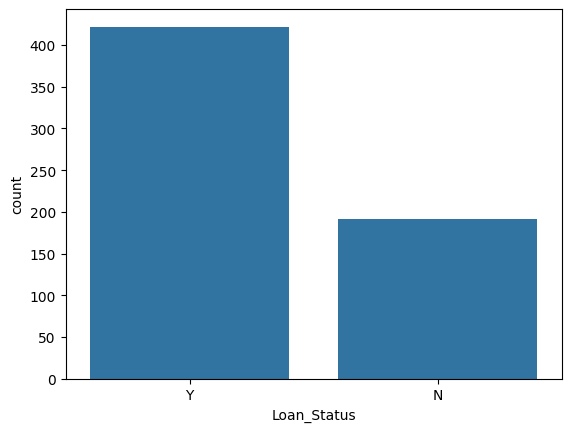

In [18]:
sns.countplot(x='Loan_Status', data=df)

In [19]:
#checking null values
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [20]:
#filling up categorical null values

def handle_cat_null(df):
  cat_cols = ('Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History')
  for i in cat_cols:
    df[i].fillna(df[i].mode()[0], inplace=True)
handle_cat_null(df)

/tmp/ipykernel_1584/4206118082.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0], inplace=True)


<Axes: xlabel='ApplicantIncome', ylabel='Count'>

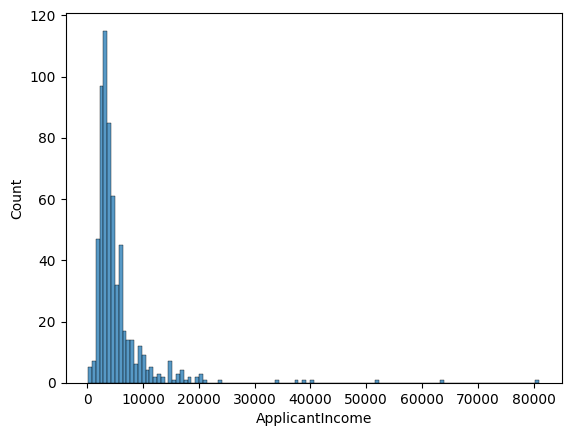

In [21]:
sns.histplot(df['ApplicantIncome'])

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

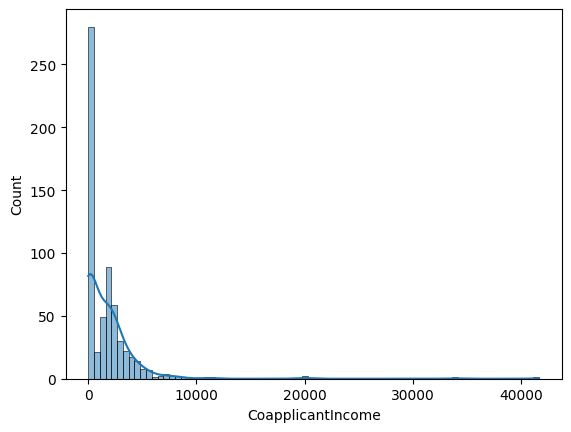

In [22]:
sns.histplot(df["CoapplicantIncome"],kde=True)

<Axes: xlabel='LoanAmount', ylabel='Count'>

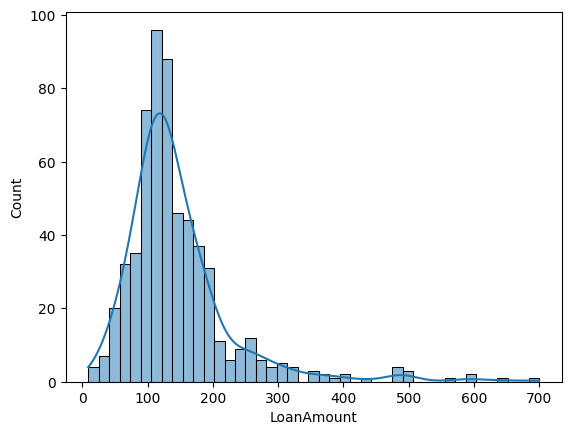

In [23]:
sns.histplot(df["LoanAmount"],kde=True)

In [24]:
#Steps to check skewness:
#1)Histogram
#2)Boxplot
#3).skew()
#4)if mean>median => Right skewed
#  if mean<median => left skewed

In [25]:
df['ApplicantIncome'].mean(), df['ApplicantIncome'].median()

(np.float64(5403.459283387622), 3812.5)

In [26]:
df['ApplicantIncome'].skew()
# value:- -0.5 to 0.5 data is centralized
# value:- >0.5 or <-0.5 data is skewed
# value:- >1 or <-1 data is highly skewed

np.float64(6.539513113994625)

In [27]:
def numeric_null(df):
  num_cols = ['LoanAmount', 'Loan_Amount_Term']
  for i in num_cols:
    df_copy[i].fillna(df_copy[i].median(), inplace=True)
numeric_null(df_copy)

/tmp/ipykernel_1584/750215522.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy[i].fillna(df_copy[i].median(), inplace=True)


In [28]:
df_copy.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [29]:
df_copy['Total_Income'] = df_copy['ApplicantIncome'] + df_copy['CoapplicantIncome']
df_copy.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0


In [30]:
# Performing encoding (one hot on object column and Label Encoding on Target Column)
# Spilitting X and Y and Splitting training and testing set
# standerizing training and testing set
# Training Logistic model
# Evaluating model

In [31]:
df_enc = df_copy.copy()


In [32]:
df_enc.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,6000.0


In [33]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
 13  Total_Income       614 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 67.3+ KB


In [34]:
df_enc['Dependents'].replace('3+',3,inplace=True)

/tmp/ipykernel_1584/1601949970.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_enc['Dependents'].replace('3+',3,inplace=True)


In [35]:
df_enc['Dependents'] = pd.to_numeric(df_enc['Dependents'])

In [36]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    float64
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
 13  Total_Income       614 non-null    float64
dtypes: float64(6), int64(2), object(6)
memory usage: 67.3+ KB


In [37]:
df_enc.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income'],
      dtype='object')

In [38]:
cat_cols = [ 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History']

df_enc = pd.get_dummies(df_enc, columns=cat_cols)


In [39]:
df_enc

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status,Total_Income,Gender_Female,Gender_Male,Married_No,...,Dependents_3.0,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Credit_History_0.0,Credit_History_1.0
0,LP001002,5849,0.0,128.0,360.0,1,5849.0,False,True,True,...,False,True,False,True,False,False,False,True,False,True
1,LP001003,4583,1508.0,128.0,360.0,0,6091.0,False,True,False,...,False,True,False,True,False,True,False,False,False,True
2,LP001005,3000,0.0,66.0,360.0,1,3000.0,False,True,False,...,False,True,False,False,True,False,False,True,False,True
3,LP001006,2583,2358.0,120.0,360.0,1,4941.0,False,True,False,...,False,False,True,True,False,False,False,True,False,True
4,LP001008,6000,0.0,141.0,360.0,1,6000.0,False,True,True,...,False,True,False,True,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,2900,0.0,71.0,360.0,1,2900.0,True,False,True,...,False,True,False,True,False,True,False,False,False,True
610,LP002979,4106,0.0,40.0,180.0,1,4106.0,False,True,False,...,True,True,False,True,False,True,False,False,False,True
611,LP002983,8072,240.0,253.0,360.0,1,8312.0,False,True,False,...,False,True,False,True,False,False,False,True,False,True
612,LP002984,7583,0.0,187.0,360.0,1,7583.0,False,True,False,...,False,True,False,True,False,False,False,True,False,True


In [40]:
x = df_enc.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df_enc['Loan_Status']

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
se = StandardScaler()
x_train = se.fit_transform(x_train)
x_test = se.transform(x_test)

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression()

In [47]:
df_enc.isnull().sum()

,0
Loan_ID,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Loan_Status,0
Total_Income,0
Gender_Female,0
Gender_Male,0
Married_No,0


In [48]:
model.fit(x_train, y_train)

LogisticRegression()

In [49]:
y_pred = model.predict(x_test)
from sklearn.metrics import accuracy_score, classification_report

In [50]:
accuracy_score(y_test, y_pred)

0.7886178861788617

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [52]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(se, 'scaler.pkl')

['scaler.pkl']